In [30]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx


def load_crime_data(
    filename: str = "data/crime_data/Criminal_Offences_Open_Data_-621494644292511792.csv",
) -> gpd.GeoDataFrame:
    df = pd.read_csv(filename)
    prev_len = len(df)

    # Drop records with missing coordinates
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df = df.dropna(subset=["x", "y"])

    # Drop old records, maintain records from 2018 to 2024
    df["Occurred Date"] = pd.to_datetime(df["Occurred Date"], errors="coerce")
    df["year"] = df["Occurred Date"].dt.year
    df = pd.DataFrame(df[df["year"].between(2018, 2024)])

    # Source coordinates are projected Ottawa-area meters (EPSG:2951).
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs="EPSG:2951")
    post_len = len(gdf)
    n_dropped = prev_len - post_len
    print(f"Records dropped: {n_dropped:,} due to missing coordinates")
    return gdf


def get_is_nighttime(gdf: gpd.GeoDataFrame) -> pd.Series:
    """
    Returns `GeoDataFrame` with nighttime indicator;
        1: nighttime
        0: not a nighttime
        -1: NaN "Occurred Hour"
    """
    sunset_hours_by_month = {
        1: 17,
        2: 17,
        3: 18,
        4: 20,
        5: 20,
        6: 21,
        7: 21,
        8: 20,
        9: 20,
        10: 19,
        11: 17,
        12: 16,
    }
    hours = gdf["Occurred Hour"] // 100
    sunset_hours = pd.Series(gdf["month"]).map(sunset_hours_by_month)

    is_after_sunset = hours >= sunset_hours
    is_before_dawn = hours < 6
    is_nighttime = (is_after_sunset | is_before_dawn).astype(int)
    return is_nighttime.where(hours.notna(), other=-1)


def parse_crime_dates(gdf: gpd.GeoDataFrame):
    gdf = gdf.copy()

    gdf["Occurred Date"] = pd.to_datetime(gdf["Occurred Date"], errors="coerce")
    # gdf["year"] = gdf["Year"].astype(int)
    gdf["month"] = gdf["Occurred Date"].dt.month
    gdf["day"] = gdf["Occurred Date"].dt.day
    gdf["year_month"] = gdf["Occurred Date"].dt.to_period("M")

    # Consider sunset hours per month to determine whether it's night
    gdf["is_nighttime"] = get_is_nighttime(gdf)

    # cols = ["is_nighttime", "Occurred Hour", "Reported Hour"]
    return gdf


def add_crime_group(gdf: gpd.GeoDataFrame):
    gdf["crime_group"] = np.where(
        gdf["is_nighttime"] == 1,
        "night",
        "non_night",
    )
    return gdf


def filter_areas(gdf: gpd.GeoDataFrame):
    min_x, min_y, max_x, max_y = (
        355000,
        5020000,  # southwest
        372000,
        5034000,  # northeast
    )

    mask = (
        (gdf.geometry.x >= min_x)
        & (gdf.geometry.x <= max_x)
        & (gdf.geometry.y >= min_y)
        & (gdf.geometry.y <= max_y)
    )

    return gpd.GeoDataFrame(gdf[mask].copy())


def assign_crimes_to_grid(crime_gdf: gpd.GeoDataFrame, grids: gpd.GeoDataFrame):
    grid_gdf = gpd.GeoDataFrame(
        grids[["cell_id", "geometry"]], geometry="geometry", crs=grids.crs
    )
    joined = gpd.sjoin(
        crime_gdf,
        grid_gdf,
        predicate="within",
        how="inner",
    )

    aggregated = joined.groupby(
        ["cell_id", "year_month", "crime_group"], observed=True
    ).size()
    aggregated = aggregated.to_frame("crime_count").reset_index()

    cells = grids["cell_id"].unique()
    months = pd.period_range(
        crime_gdf["year_month"].min(),
        crime_gdf["year_month"].max(),
        freq="M",
    )
    crime_groups = ["night", "non_night"]
    neighbourhood = crime_gdf["Neighbourhood Name"].unique()

    # Full skeleton
    full_index = pd.MultiIndex.from_product(
        [cells, months, crime_groups, neighbourhood],
        names=["cell_id", "year_month", "crime_group", "neighbourhood"],
    )
    panel = pd.DataFrame(index=full_index).reset_index()
    panel = panel.merge(
        aggregated,
        on=["cell_id", "year_month", "crime_group"],
        how="left",
    )
    panel["crime_count"] = panel["crime_count"].fillna(0).astype(int)
    panel = panel.sort_values(["cell_id", "crime_group", "year_month"])

    return panel


def add_crime_features(df: pd.DataFrame):
    # Accumulated crime count
    df["total_crime_count"] = (
        df.groupby("cell_id")["crime_count"].cumsum().shift(1).fillna(0)
    )

    # Average crime count
    df["avg_crime_count"] = (
        df.groupby("cell_id")["crime_count"]
        .expanding()
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
        .fillna(0)
    )

    # Previous crime count
    df["prev_crime_count"] = df.groupby("cell_id")["crime_count"].shift(1).fillna(0)
    return df


def plot_crime_hexbin(crime_gdf, is_filtered=False):
    crime_plot = crime_gdf.to_crs(epsg=3857)

    x = crime_plot.geometry.x
    y = crime_plot.geometry.y

    fig, ax = plt.subplots(figsize=(14, 12))

    hb = ax.hexbin(
        x,
        y,
        gridsize=60,
        cmap="inferno",
        mincnt=1,
        bins="log",
    )

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=crime_plot.crs, zoom=12)

    ax.set_aspect("equal")
    ax.set_title("Crime Density (Hexbin)")
    ax.axis("off")

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Crime Count")

    plt.tight_layout()
    if is_filtered:
        plt.savefig("test.png", dpi=300)
    else:
        plt.savefig("og.png", dpi=300)
    plt.show()


def print_crime_ratios(panel: pd.DataFrame):
    non_zeros = panel[panel["crime_count"] > 0]
    non_zero_count = len(non_zeros)
    zeros = panel[panel["crime_count"] == 0]
    zero_count = len(zeros)
    print(f"Non-zero: {non_zero_count:,}")
    print(f"Zero: {zero_count:,}")
    print(
        f"Non-zero ratio: {non_zero_count / (non_zero_count + zero_count) * 100:.2f}%"
    )


def build_grid_cells(gdf: gpd.GeoDataFrame, cell_size: int = 50):
    min_x, min_y, max_x, max_y = gdf.total_bounds
    x_range = np.arange(min_x, max_x + cell_size, cell_size)
    y_range = np.arange(min_y, max_y + cell_size, cell_size)

    cells, cell_ids = [], []
    for i, x in enumerate(x_range):
        for j, y in enumerate(y_range):
            x, y = float(x), float(y)
            grid = box(x, y, x + cell_size, y + cell_size)
            cells.append(grid)
            cell_ids.append(i * (len(y_range) - 1) + j)

    grids = gpd.GeoDataFrame({"cell_id": cell_ids, "geometry": cells}, crs=gdf.crs)
    grids["centroid_x"] = grids.geometry.centroid.x
    grids["centroid_y"] = grids.geometry.centroid.y
    print(f"Grid cells created: {len(grids):,}, {grids.crs}")
    return grids

============ CRIME DATA ============ 
Records dropped: 7,310 due to missing coordinates
95,383 dropped after filtering areas


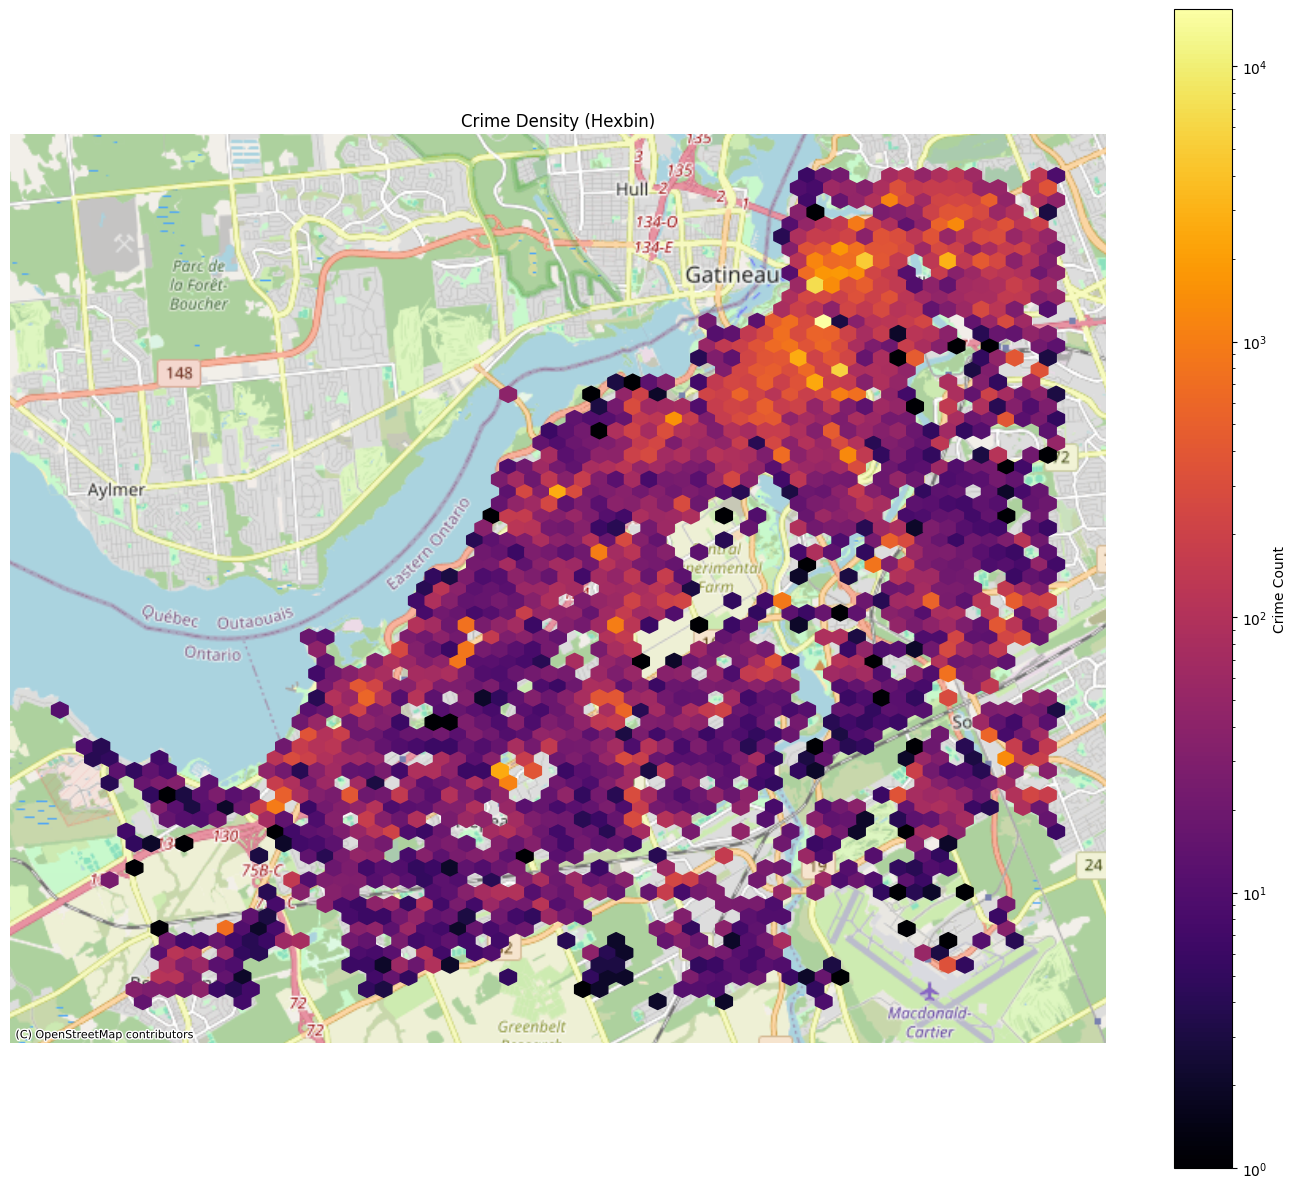

Grid cells created: 1,584, EPSG:2951
Non-zero: 3,202,542
Zero: 13,107,402
Non-zero ratio: 19.64%


In [31]:
from shapely.geometry import box


def preprocess_crime_data():
    print("============ CRIME DATA ============ ")
    par_dir = "data"
    crime_data_name = "crime_data/Criminal_Offences_Open_Data_-621494644292511792.csv"
    crime_data_name = f"{crime_data_name}"

    crime_gdf = load_crime_data(crime_data_name)
    crime_gdf = parse_crime_dates(crime_gdf)
    crime_gdf = add_crime_group(crime_gdf)

    prev_len = len(crime_gdf)
    crime_gdf = filter_areas(crime_gdf)
    post_len = len(crime_gdf)
    print(f"{prev_len - post_len:,} dropped after filtering areas")
    plot_crime_hexbin(crime_gdf, True)

    if crime_gdf.crs is None or crime_gdf.crs.to_epsg() != 2951:
        crime_gdf = crime_gdf.to_crs(epsg=2951)
    grids = build_grid_cells(crime_gdf, 400)

    panel = assign_crimes_to_grid(crime_gdf, grids)
    panel = add_crime_features(panel)
    print_crime_ratios(panel)
    return panel, grids


panel, grids = preprocess_crime_data()

In [41]:
import matplotlib.colors as mcolors


def remove_outliers(df: pd.DataFrame, col: str):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]


def load_street_light_data(filename: str = "data/street_light_data/Street_Lights.csv"):
    df = pd.read_csv(filename)
    prev_len = len(df)
    df["X"] = pd.to_numeric(df["X"], errors="coerce")
    df["Y"] = pd.to_numeric(df["Y"], errors="coerce")
    df = df.dropna(subset=["X", "Y"])

    df = pd.DataFrame(remove_outliers(df, "X"))
    df = pd.DataFrame(remove_outliers(df, "Y"))

    df["intensity"] = df["WATTAGE"] * df["LIGHTS_NUM"]

    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.X, df.Y), crs="EPSG:3857")
    post_len = len(gdf)
    n_dropped = prev_len - post_len
    print(f"Records dropped: {n_dropped:,} due to missing coordinates")

    return gdf


def assign_street_lights_to_grid(gdf: gpd.GeoDataFrame, grids: gpd.GeoDataFrame):
    if gdf.crs is None or grids.crs is None:
        raise ValueError("Both street light and grid GeoDataFrames must have a CRS.")
    if gdf.crs != grids.crs:
        gdf = gdf.to_crs(grids.crs)

    grid_gdf = gpd.GeoDataFrame(
        grids[["cell_id", "geometry"]], geometry="geometry", crs=grids.crs
    )
    print(f"Before join: {len(gdf)}")
    joined = gpd.sjoin(gdf, grid_gdf, predicate="within", how="inner")
    print(f"After join: {len(joined)}")

    aggregated = (
        joined.groupby("cell_id")
        .agg(
            light_count=("LIGHTS_NUM", "sum"),
            total_wattage=("WATTAGE", "sum"),
            total_intensity=("intensity", "sum"),
            avg_wattage=("WATTAGE", "mean"),
        )
        .reset_index()
    )
    return aggregated


def plot_street_lights(gdf: gpd.GeoDataFrame):
    gdf = gdf.to_crs(epsg=3857)
    x = gdf.geometry.x
    y = gdf.geometry.y
    _, ax = plt.subplots(figsize=(14, 12))
    hb = ax.hexbin(
        x,
        y,
        C=gdf["intensity"],
        reduce_C_function=np.sum,
        gridsize=150,
        cmap="YlOrRd",
        norm=mcolors.LogNorm(),
        alpha=0.75,
        linewidths=0,
    )
    ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_aspect("equal")

    cbar = plt.colorbar(hb, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Intensity", color="white", fontsize=11)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    ax.set_axis_off()
    plt.title(
        "Street Light Intensity Map",
        color="white",
        fontsize=16,
        fontweight="bold",
        pad=12,
    )
    plt.tight_layout()
    plt.show()


============ STREET LIGHT DATA ============ 
Records dropped: 1,714 due to missing coordinates


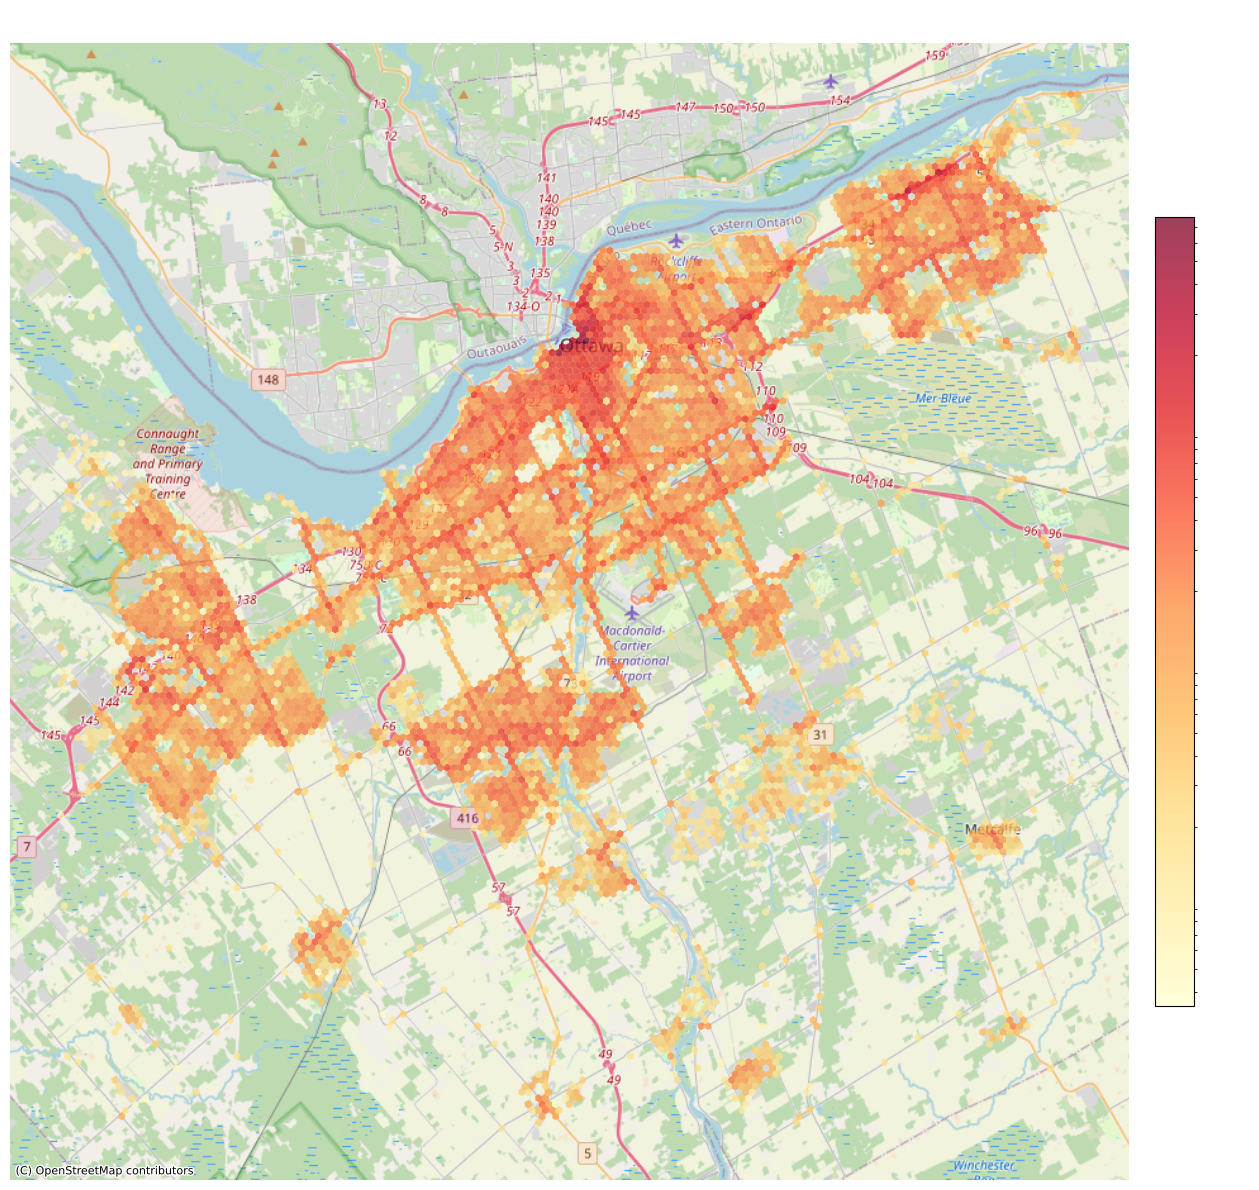

Before join: 78956
After join: 34017


In [42]:
def preprocess_street_light_data():
    print("============ STREET LIGHT DATA ============ ")
    par_dir = "data"
    street_light_name = "street_light_data/Street_Lights.csv"
    street = f"{street_light_name}"

    light_gdf = load_street_light_data(street)
    plot_street_lights(light_gdf)

    return light_gdf


light = preprocess_street_light_data()
lights_cell = assign_street_lights_to_grid(light, grids)

In [ ]:
data_panel = panel.merge(lights_cell, on="cell_id", how="left")
light_feats = ["light_count", "total_wattage", "total_intensity", "avg_wattage"]
data_panel[light_feats] = data_panel[light_feats].fillna(0)

# Final Aggregation (coordinates included)
grid_info = ["cell_id", "geometry", "centroid_x", "centroid_y"]
data_panel = data_panel.merge(
    grids[grid_info],
    on="cell_id",
    how="left",
)
data_panel = gpd.GeoDataFrame(data_panel, geometry="geometry", crs=grids.crs)
data_panel
# Save
# data_panel.to_parquet("data/data_panel.parquet", index=False)
# data_panel.to_file("data/data_panel.gpkg", layer="data_panel", driver="GPKG")

,cell_id,year_month,crime_group,neighbourhood,crime_count,total_crime_count,avg_crime_count,prev_crime_count,light_count,total_wattage,total_intensity,avg_wattage,geometry,centroid_x,centroid_y
0,0,2018-01,night,Carlington,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((355597.648 5020000.479, 355597.648 5...",355397.6479,5.020200e+06
1,0,2018-01,night,Centretown,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((355597.648 5020000.479, 355597.648 5...",355397.6479,5.020200e+06
2,0,2018-01,night,Glebe - Dows Lake,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((355597.648 5020000.479, 355597.648 5...",355397.6479,5.020200e+06
3,0,2018-01,night,Byward Market,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((355597.648 5020000.479, 355597.648 5...",355397.6479,5.020200e+06
4,0,2018-01,night,Tanglewood,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((355597.648 5020000.479, 355597.648 5...",355397.6479,5.020200e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16765051,1540,2024-12,non_night,NaN,0,0.0,0.0,0.0,47.0,6027.0,6027.0,128.234043,"POLYGON ((372797.648 5034000.479, 372797.648 5...",372597.6479,5.034200e+06
16765052,1540,2024-12,non_night,Greenbelt - Shirleys Bay,0,0.0,0.0,0.0,47.0,6027.0,6027.0,128.234043,"POLYGON ((372797.648 5034000.479, 372797.648 5...",372597.6479,5.034200e+06
16765053,1540,2024-12,non_night,Notre-Dame Cemetery,0,0.0,0.0,0.0,47.0,6027.0,6027.0,128.234043,"POLYGON ((372797.648 5034000.479, 372797.648 5...",372597.6479,5.034200e+06
16765054,1540,2024-12,non_night,Stittsville,0,0.0,0.0,0.0,47.0,6027.0,6027.0,128.234043,"POLYGON ((372797.648 5034000.479, 372797.648 5...",372597.6479,5.034200e+06


In [40]:
print(f"Total Records: {len(data_panel)}")
non_zero = data_panel["crime_count"] != 0
zero = data_panel["crime_count"] == 0
print(f"Non-Zero Records: {len(data_panel[non_zero])}")
print(f"Zero Records: {len(data_panel[zero])}")

Total Records: 16765056
Non-Zero Records: 3227301
Zero Records: 13537755
